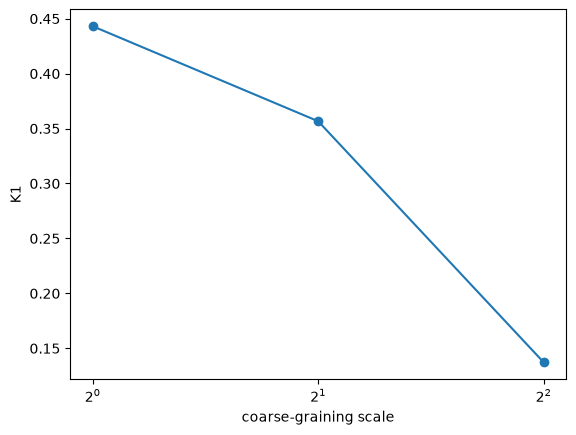

In [3]:
import sys

sys.path.append("../src")

from core.data.ising import Ising2D
from core.coarse_graining.block import MajorityBlockSpin
from core.operators.base import OperatorBasis
from core.operators.ising import NearestNeighbor
from core.inference.ising import InferK1
from core.inference.base import infer_couplings
from core.rgflow.flow import RGFlow
import matplotlib.pyplot as plt


ising = Ising2D(L=8)

cg = MajorityBlockSpin(block_size=2)

samples = ising.sample(n_samples=10)
coarse1_samples = cg.transform(samples)
coarse2_samples = cg.transform(coarse1_samples)

basis = OperatorBasis()
basis.add_operator(NearestNeighbor())

running_coupling = infer_couplings(samples, basis, InferK1())
running_coupling1 = infer_couplings(coarse1_samples, basis, InferK1())
running_coupling2 = infer_couplings(coarse2_samples, basis, InferK1())

flow = RGFlow([running_coupling, running_coupling1, running_coupling2])


plt.plot([1.0, 2.0, 4.0], flow.values("K1"), "o-")
plt.xlabel("coarse-graining scale")
plt.ylabel("K1")
plt.xscale("log", base=2)
